In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

llm = ChatGroq(model ='qwen/qwen3.8-27b')

In [3]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [5]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

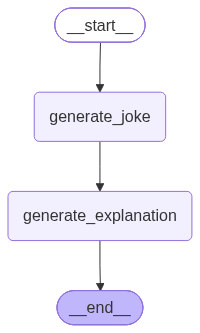

In [7]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [8]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza break up with the salad?\n\nBecause it felt like they had too many **crusts** in common and not enough **toppings** for a healthy relationship! 🍕🥗',
 'explanation': 'This joke is a classic example of a **pun** (a play on words) that relies on double meanings to create humor. Here’s a breakdown of why it works:\n\n### 1. The Core Pun: "Crusts" vs. "Cruelty" or just "Commonalities"\nThe phrase **“had too many crusts in common”** is a playful twist on the common expression **“had too much in common”** or sometimes even **“too much crust”** (as in, you’re being too tough or stubborn).  \n- **Literal meaning:** Pizza literally has a crust.  \n- **Figurative meaning:** In relationships, having “too much in common” is usually seen as a *good* thing, but here it’s framed as a problem because it’s *literally* about food parts. The humor comes from taking a serious relationship concern and applying it to pizza’s physical structure.\n\n### 2. The Wor

In [9]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza break up with the salad?\n\nBecause it felt like they had too many **crusts** in common and not enough **toppings** for a healthy relationship! 🍕🥗', 'explanation': 'This joke is a classic example of a **pun** (a play on words) that relies on double meanings to create humor. Here’s a breakdown of why it works:\n\n### 1. The Core Pun: "Crusts" vs. "Cruelty" or just "Commonalities"\nThe phrase **“had too many crusts in common”** is a playful twist on the common expression **“had too much in common”** or sometimes even **“too much crust”** (as in, you’re being too tough or stubborn).  \n- **Literal meaning:** Pizza literally has a crust.  \n- **Figurative meaning:** In relationships, having “too much in common” is usually seen as a *good* thing, but here it’s framed as a problem because it’s *literally* about food parts. The humor comes from taking a serious relationship concern and applying it to pizza’s physical structure

In [10]:
list (workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza break up with the salad?\n\nBecause it felt like they had too many **crusts** in common and not enough **toppings** for a healthy relationship! 🍕🥗', 'explanation': 'This joke is a classic example of a **pun** (a play on words) that relies on double meanings to create humor. Here’s a breakdown of why it works:\n\n### 1. The Core Pun: "Crusts" vs. "Cruelty" or just "Commonalities"\nThe phrase **“had too many crusts in common”** is a playful twist on the common expression **“had too much in common”** or sometimes even **“too much crust”** (as in, you’re being too tough or stubborn).  \n- **Literal meaning:** Pizza literally has a crust.  \n- **Figurative meaning:** In relationships, having “too much in common” is usually seen as a *good* thing, but here it’s framed as a problem because it’s *literally* about food parts. The humor comes from taking a serious relationship concern and applying it to pizza’s physical structur

In [11]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)


{'topic': 'pasta',
 'joke': 'Why did the spaghetti break up with the macaroni?\n\nBecause they had too many **knots** to work out, and it just wasn’t **al dente** anymore. 🍝',
 'explanation': 'This joke is a classic example of a **pun** (a play on words) that relies on double meanings associated with cooking and relationships. Here is the breakdown of why it is funny:\n\n### 1. "Knots"\n*   **Literal meaning:** When spaghetti is cooked, the long strands can tangle and form literal knots.\n*   **Figurative meaning:** In relationships, "knots" refers to complications, problems, or emotional tangles that a couple needs to "work out" or resolve.\n*   **The Joke:** The spaghetti and macaroni are breaking up because their relationship has become too complicated (too many tangles/knots) to fix.\n\n### 2. "Al dente"\n*   **Literal meaning:** *Al dente* is an Italian culinary term meaning "to the tooth." It describes pasta that is cooked until it is firm to the bite, not soft or mushy.\n*   **F

In [12]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the macaroni?\n\nBecause they had too many **knots** to work out, and it just wasn’t **al dente** anymore. 🍝', 'explanation': 'This joke is a classic example of a **pun** (a play on words) that relies on double meanings associated with cooking and relationships. Here is the breakdown of why it is funny:\n\n### 1. "Knots"\n*   **Literal meaning:** When spaghetti is cooked, the long strands can tangle and form literal knots.\n*   **Figurative meaning:** In relationships, "knots" refers to complications, problems, or emotional tangles that a couple needs to "work out" or resolve.\n*   **The Joke:** The spaghetti and macaroni are breaking up because their relationship has become too complicated (too many tangles/knots) to fix.\n\n### 2. "Al dente"\n*   **Literal meaning:** *Al dente* is an Italian culinary term meaning "to the tooth." It describes pasta that is cooked until it is firm to the bite, not soft

In [15]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza break up with the salad?\n\nBecause it felt like they had too many **crusts** in common and not enough **toppings** for a healthy relationship! 🍕🥗', 'explanation': 'This joke is a classic example of a **pun** (a play on words) that relies on double meanings to create humor. Here’s a breakdown of why it works:\n\n### 1. The Core Pun: "Crusts" vs. "Cruelty" or just "Commonalities"\nThe phrase **“had too many crusts in common”** is a playful twist on the common expression **“had too much in common”** or sometimes even **“too much crust”** (as in, you’re being too tough or stubborn).  \n- **Literal meaning:** Pizza literally has a crust.  \n- **Figurative meaning:** In relationships, having “too much in common” is usually seen as a *good* thing, but here it’s framed as a problem because it’s *literally* about food parts. The humor comes from taking a serious relationship concern and applying it to pizza’s physical structur

In [16]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1b0264-bd7b-6612-8000-fd943fc1b5ad"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1b0264-bd7b-6612-8000-fd943fc1b5ad'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-14T10:23:15.286982+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b0264-bd79-68bc-bfff-3f550e133ca7'}}, tasks=(PregelTask(id='ff7555f1-e3d5-aaa8-421e-46011a4f0bf3', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza break up with the salad?\n\nBecause it felt like they had too many **crusts** in common and not enough **toppings** for a healthy relationship! 🍕🥗'}),), interrupts=())

In [17]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1b0264-bd7b-6612-8000-fd943fc1b5ad"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor?\n\nBecause it wasn’t feeling **whole**. 🍕🩺',
 'explanation': 'This joke is a classic example of a **pun** that relies on a **double meaning** (or polysemy) of the word **"whole."**\n\nHere’s the breakdown:\n\n1.  **The Setup:** The question "Why did the pizza go to the doctor?" immediately sets up an expectation that the pizza is sick, injured, or experiencing a problem that requires medical attention.\n2.  **The Punchline:** "Because it wasn’t feeling **whole**."\n    *   **Meaning 1 (Emotional/Physical State):** To "feel whole" means to feel complete, healthy, or intact. If you’re not feeling whole, you might be feeling broken, sick, or unwell — a common reason to visit a doctor.\n    *   **Meaning 2 (Literal Shape):** A pizza is typically a **whole** circle. If it’s been sliced, eaten, or cut, it is no longer "whole."\n3.  **The Humor:** The joke plays on the ambiguity of the word "whole." It sounds like the pizza is e

In [18]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\n\nBecause it wasn’t feeling **whole**. 🍕🩺', 'explanation': 'This joke is a classic example of a **pun** that relies on a **double meaning** (or polysemy) of the word **"whole."**\n\nHere’s the breakdown:\n\n1.  **The Setup:** The question "Why did the pizza go to the doctor?" immediately sets up an expectation that the pizza is sick, injured, or experiencing a problem that requires medical attention.\n2.  **The Punchline:** "Because it wasn’t feeling **whole**."\n    *   **Meaning 1 (Emotional/Physical State):** To "feel whole" means to feel complete, healthy, or intact. If you’re not feeling whole, you might be feeling broken, sick, or unwell — a common reason to visit a doctor.\n    *   **Meaning 2 (Literal Shape):** A pizza is typically a **whole** circle. If it’s been sliced, eaten, or cut, it is no longer "whole."\n3.  **The Humor:** The joke plays on the ambiguity of the word "whole." It sounds

In [19]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1b0264-bd7b-6612-8000-fd943fc1b5ad", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b0298-4581-6957-8001-46d728e0e53c'}}

In [20]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b0298-4581-6957-8001-46d728e0e53c'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-09-14T10:46:18.570980+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b0264-bd7b-6612-8000-fd943fc1b5ad'}}, tasks=(PregelTask(id='586265c7-4d90-45ce-094f-83d29a0e6421', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\n\nBecause it wasn’t feeling **whole**. 🍕🩺', 'explanation': 'This joke is a classic example of a **pun** that relies on a **double meaning** (or polysemy) of the word **"whole."**\n\nHere’s the breakdown:\n\n1.  **The Setup:** The question "Why did the pizza go to the doctor?" immediately sets

In [22]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1b0298-4581-6957-8001-46d728e0e53c"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it had too many **fillings** left unexpressed! 🥟😂',
 'explanation': 'Here is the explanation for the joke:\n\nThis is a classic example of a **pun** (a play on words) that relies on the double meaning of the word **"fillings."**\n\n1.  **Literal Meaning:** In the context of a **samosa** (a popular stuffed pastry), "fillings" refers to the ingredients inside it, such as potatoes, peas, or meat.\n2.  **Figurative/Psychological Meaning:** In the context of **therapy**, people often talk about "suppressing" or keeping their **feelings** (emotions) inside without expressing them. The joke swaps "feelings" with "fillings," creating a humorous and absurd image of a food item needing emotional counseling because it’s "holding in" its ingredients.\n\n**Why it’s funny:**\n*   It personifies a piece of food, giving it human-like emotional struggles.\n*   It subtly puns on the similar sound and spelling of **"fillings"** vs

In [23]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it had too many **fillings** left unexpressed! 🥟😂', 'explanation': 'Here is the explanation for the joke:\n\nThis is a classic example of a **pun** (a play on words) that relies on the double meaning of the word **"fillings."**\n\n1.  **Literal Meaning:** In the context of a **samosa** (a popular stuffed pastry), "fillings" refers to the ingredients inside it, such as potatoes, peas, or meat.\n2.  **Figurative/Psychological Meaning:** In the context of **therapy**, people often talk about "suppressing" or keeping their **feelings** (emotions) inside without expressing them. The joke swaps "feelings" with "fillings," creating a humorous and absurd image of a food item needing emotional counseling because it’s "holding in" its ingredients.\n\n**Why it’s funny:**\n*   It personifies a piece of food, giving it human-like emotional struggles.\n*   It subtly puns on the similar sound and spelling 